In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("House Price Prediction Dataset.csv")
df.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [4]:
df.dtypes

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Location'] = le.fit_transform(df['Location'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df.dtypes

Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location     int64
Condition    int64
Garage       int64
Price        int64
dtype: object

In [24]:
df_missing = df.copy()
df_missing.loc[0:5, 'Price'] = np.nan
df_missing.isna().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        6
dtype: int64

In [25]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (2000, 10)
After removing some values:  (2000, 10)


In [26]:
df_missing.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,NaN
1,2,4272,5,4,3,1958,0,0,0,NaN
2,3,3592,2,2,3,1938,0,2,0,NaN
3,4,966,4,2,2,1902,2,1,1,NaN
4,5,4926,1,4,2,1975,0,1,1,NaN
5,6,3944,1,2,1,1906,3,3,0,NaN
6,7,3671,1,1,2,1948,1,3,1,448722.0
7,8,3419,2,4,1,1925,2,2,1,594893.0
8,9,630,2,2,1,1932,1,3,1,652878.0
9,10,2185,3,3,1,2000,0,3,0,340375.0


In [27]:
df_removed = df_missing.dropna()
df_removed.shape

(1994, 10)

In [28]:
df_removed.isna().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [29]:
df_missing.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,NaN
1,2,4272,5,4,3,1958,0,0,0,NaN
2,3,3592,2,2,3,1938,0,2,0,NaN
3,4,966,4,2,2,1902,2,1,1,NaN
4,5,4926,1,4,2,1975,0,1,1,NaN
5,6,3944,1,2,1,1906,3,3,0,NaN
6,7,3671,1,1,2,1948,1,3,1,448722.0
7,8,3419,2,4,1,1925,2,2,1,594893.0
8,9,630,2,2,1,1932,1,3,1,652878.0
9,10,2185,3,3,1,2000,0,3,0,340375.0


In [32]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Price'].fillna(df_imputed_mean['Price'].mean(), inplace=True)

df_imputed_mean.isna().sum()

/var/folders/dp/cfr30n9170v6tv_ywg6nm_gh0000gn/T/ipykernel_47052/1310457215.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['Price'].fillna(df_imputed_mean['Price'].mean(), inplace=True)


Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [33]:
df_imputed_mean.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,538384.508024
1,2,4272,5,4,3,1958,0,0,0,538384.508024
2,3,3592,2,2,3,1938,0,2,0,538384.508024
3,4,966,4,2,2,1902,2,1,1,538384.508024
4,5,4926,1,4,2,1975,0,1,1,538384.508024
5,6,3944,1,2,1,1906,3,3,0,538384.508024
6,7,3671,1,1,2,1948,1,3,1,448722.000000
7,8,3419,2,4,1,1925,2,2,1,594893.000000
8,9,630,2,2,1,1932,1,3,1,652878.000000
9,10,2185,3,3,1,2000,0,3,0,340375.000000


In [35]:
df_imputed_median = df_missing.copy()
df_imputed_median['Price'].fillna(df_imputed_median['Price'].median(), inplace=True)

df_imputed_median.isna().sum()

/var/folders/dp/cfr30n9170v6tv_ywg6nm_gh0000gn/T/ipykernel_47052/1945399632.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['Price'].fillna(df_imputed_median['Price'].median(), inplace=True)


Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [16]:
df_imputed_median.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Amount
0,1,1360,5,4,3,1970,0,0,0,149919,NaN
1,2,4272,5,4,3,1958,0,0,0,424998,NaN
2,3,3592,2,2,3,1938,0,2,0,266746,NaN
3,4,966,4,2,2,1902,2,1,1,244020,NaN
4,5,4926,1,4,2,1975,0,1,1,636056,NaN
5,6,3944,1,2,1,1906,3,3,0,93262,NaN
6,7,3671,1,1,2,1948,1,3,1,448722,NaN
7,8,3419,2,4,1,1925,2,2,1,594893,NaN
8,9,630,2,2,1,1932,1,3,1,652878,NaN
9,10,2185,3,3,1,2000,0,3,0,340375,NaN


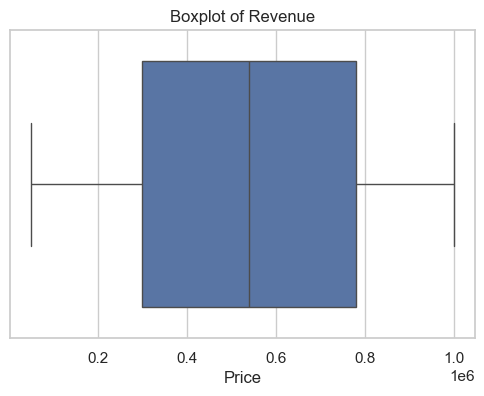

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Revenue")
plt.show()

In [54]:
df_no_outliers = df[(df['Price'] >= lower) & (df['Price'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (2000, 10)
After removing outliers:  (2000, 10)


In [43]:
lower_cap = df['Price'].quantile(0.05)
upper_cap = df['Price'].quantile(0.95)

df_capped = df.copy()
df_capped['Price'] = df_capped['Price'].clip(lower_cap, upper_cap)

In [46]:
df[['Price', 'Area']].head()

,Price,Area
0,149919,1360
1,424998,4272
2,266746,3592
3,244020,966
4,636056,4926


In [47]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Price', 'Area']].copy()

df_scaled[['Price', 'Area']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Price,Area
0,0.105211,0.190974
1,0.394875,0.838373
2,0.228232,0.687194
3,0.204301,0.103379
4,0.617123,0.983771


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Price', 'Area']].copy()

df_standardized[['Price', 'Area']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Price,Area
0,-1.403091,-1.101471
1,-0.407725,1.147485
2,-0.980356,0.622317
3,-1.062589,-1.405759
4,0.355982,1.652574


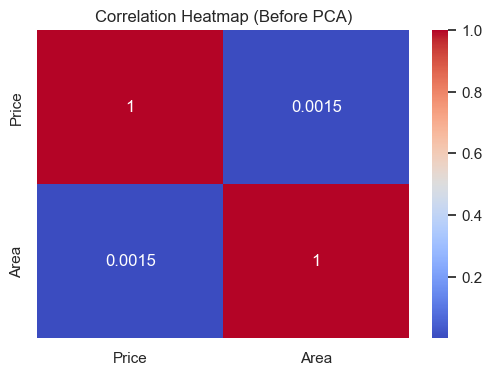

In [50]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Price', 'Area']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [51]:
from sklearn.decomposition import PCA

X = df_standardized[['Price', 'Area']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50077106 0.49922894]


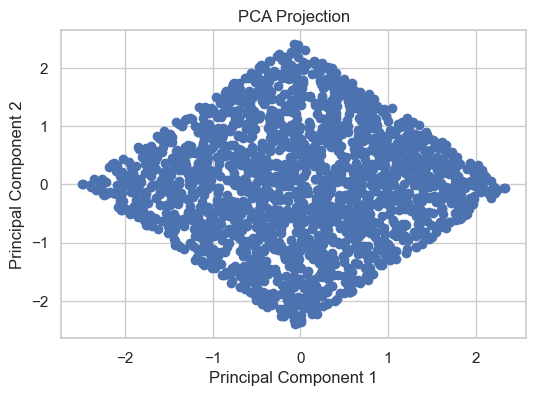

In [53]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of lab 4.